# Exploração

**Maj Diego / 2º semestre de 2026**

**Objetivos**

1. Comparar o SLAM 100 com um Scanner homólogo 
2. Explicar a pasta de dados proprietários de um levantamento via SLAM 100


## 1. X120 vs SLAM100

| <a href="media/manuais/X120GO_UserGuide_ENG.pdf">STONEX X120</a>  |  <a href="media/manuais/Slam 100 product manual.pdf">FEIMA ROBOTICS SLAM 100</a>|
|-|-|
|Origem: Italiano<br>Laser Scanning FOV: 270°×360° <br> Camera FOV: 200° ( H ) x 100° ( V )<br> Absolute Accuracy: 5cm  <br> Laser Pulse Repetition Rate: 320kHz <br>Maximum Range: 120m <br>Camera Resolution: 5MP <br>Weight: 1,6Kg <br> Laser channels: 16<br> WIFI Password: 12345678<br>App: GOApp| Origem: Chinês <br>Laser Scanning FOV: 270°×360° <br> Camera FOV: 200° ( H ) x 100° ( V )<br> Absolute Accuracy: 5cm  <br> Laser Pulse Repetition Rate: 320kHz <br>Maximum Range: 120m <br>Camera Resolution: 5MP <br>Weight: 1,6Kg <br> Laser channels: 16<br> WIFI Password: 12345678<br> App: SLAM GO|
|<center><img src="media/imgs/arquivos_raw_x120go.jpeg"></center> | <center><img src="media/imgs/arquivos_raw_slam100.jpg"></center> |
|<center><img src="media/imgs/x120go_home.png"></center> | <center><img src="media/imgs/slamgo_home.jpeg"></center> |
|**4.1 How to use X120GO without application** <br> • Turn on the scanner by pressing the power button for a couple of seconds and wait for the LiDAR head to start rotating.<br> • Place the scanner in a stable spot for initialisation. Press the power button once quickly. The green LED will start flashing indicating that the instrument is acquiring data correctly. <br> • Wait one minute for the instrument to initialise. Make sure that there are no persons or objects moving in front nearby.<br> • After one minute has passed, begin acquisition normally.<br> • If you wish to acquire a control point, place the scanner over a target or recognisable point and stand over this point for at least 10 seconds. After 10 seconds resume scanning normally.<br> • To end the scan, press the power button once quickly. The green LED will stop flashing, indicating the end of data acquisition. | **Device power on** <br> • Press the scanner on key for 3 seconds for a long time, and the status indicator light is always green (the battery is fully charged). Wait for the laser head to start rotating, and then the device starts successfully.<br>  **Start collecting** <br> • Press the scanner on key, and the data acquisition function will be turned on. At this time, the status indicator will turn green (the battery is fully charged) and blink.|
|**API**: Não informado | **API** (https://wiki.feima.cool/en/sdk/slam/http):  <br> • Starting the Device: <br> ••  <code>curl --location --request GET 'http://192.168.10.1:19700/slam/start_work'</code> <br> • Status Check Command: <br> •• <code>curl --location --request GET 'http://192.168.10.1:19700/slam/get_error_status'</code>  <br> • Stopping the Device:  <br> •• <code>curl --location --request GET 'http://192.168.10.1:19700/slam/end_work'</code> <br>• Get SSD Info:<br> •• <code>curl --location --request GET 'http://192.168.10.1:19700/slam2000/get_ssd_info'</code> <br> • Get Real-Time Mapping Status:<br> •• <code>curl --location --request GET 'http://192.168.10.1:19700/slam/get_mapping_info'</code> <br> • Get Battery State <br> •• <code>curl --location --request GET 'http://192.168.10.1:19700/slam2000/get_battery_state'</code>   |
|<center><img src="media/imgs/outdoorstonex.jpeg"><center>|<center><img src="media/imgs/outdoorfeima.jpeg"><center>|

## 2. Pasta de dados proprietários de um levantamento


In [1]:
# Coloque a pasta de dados SN_00040 duas pastas acima do diretório atual
import os
print(os.listdir(".."))
dados_dir = "../SN_00040/PROJ1"

['app SLAM GO', 'exported', 'git', 'IME_lidar', 'jadx-1-5-3', 'SlamProject', 'SN_00040', 'SN_00040.zip', 'SN_00041', 'SN_00042', 'SN_00043', 'SN_00044', 'SN_00045', 'SN_00046', 'SN_00047', 'SN_00048', 'SN_00049', 'table_scanner.html']


In [2]:
# O que tem dentro da pasta de dados?
os.listdir(dados_dir)

['20250610-163659_00040_Ec_Data.fmraster',
 '20250610-163659_00040_Lp_Imu.fmimr',
 '20250610-163659_00040_SLAM_Pandar_0001_0.pcap',
 'camera0',
 'camera1',
 'camera2',
 'feima_slam100_calib.yaml',
 'PointPhoto',
 'task_info.txt']

#### 2.1 As imagens

Quantidade de frames da câmera 1: 483
cam1_pic0_Tuesday-16-37-01-064627.jpeg:


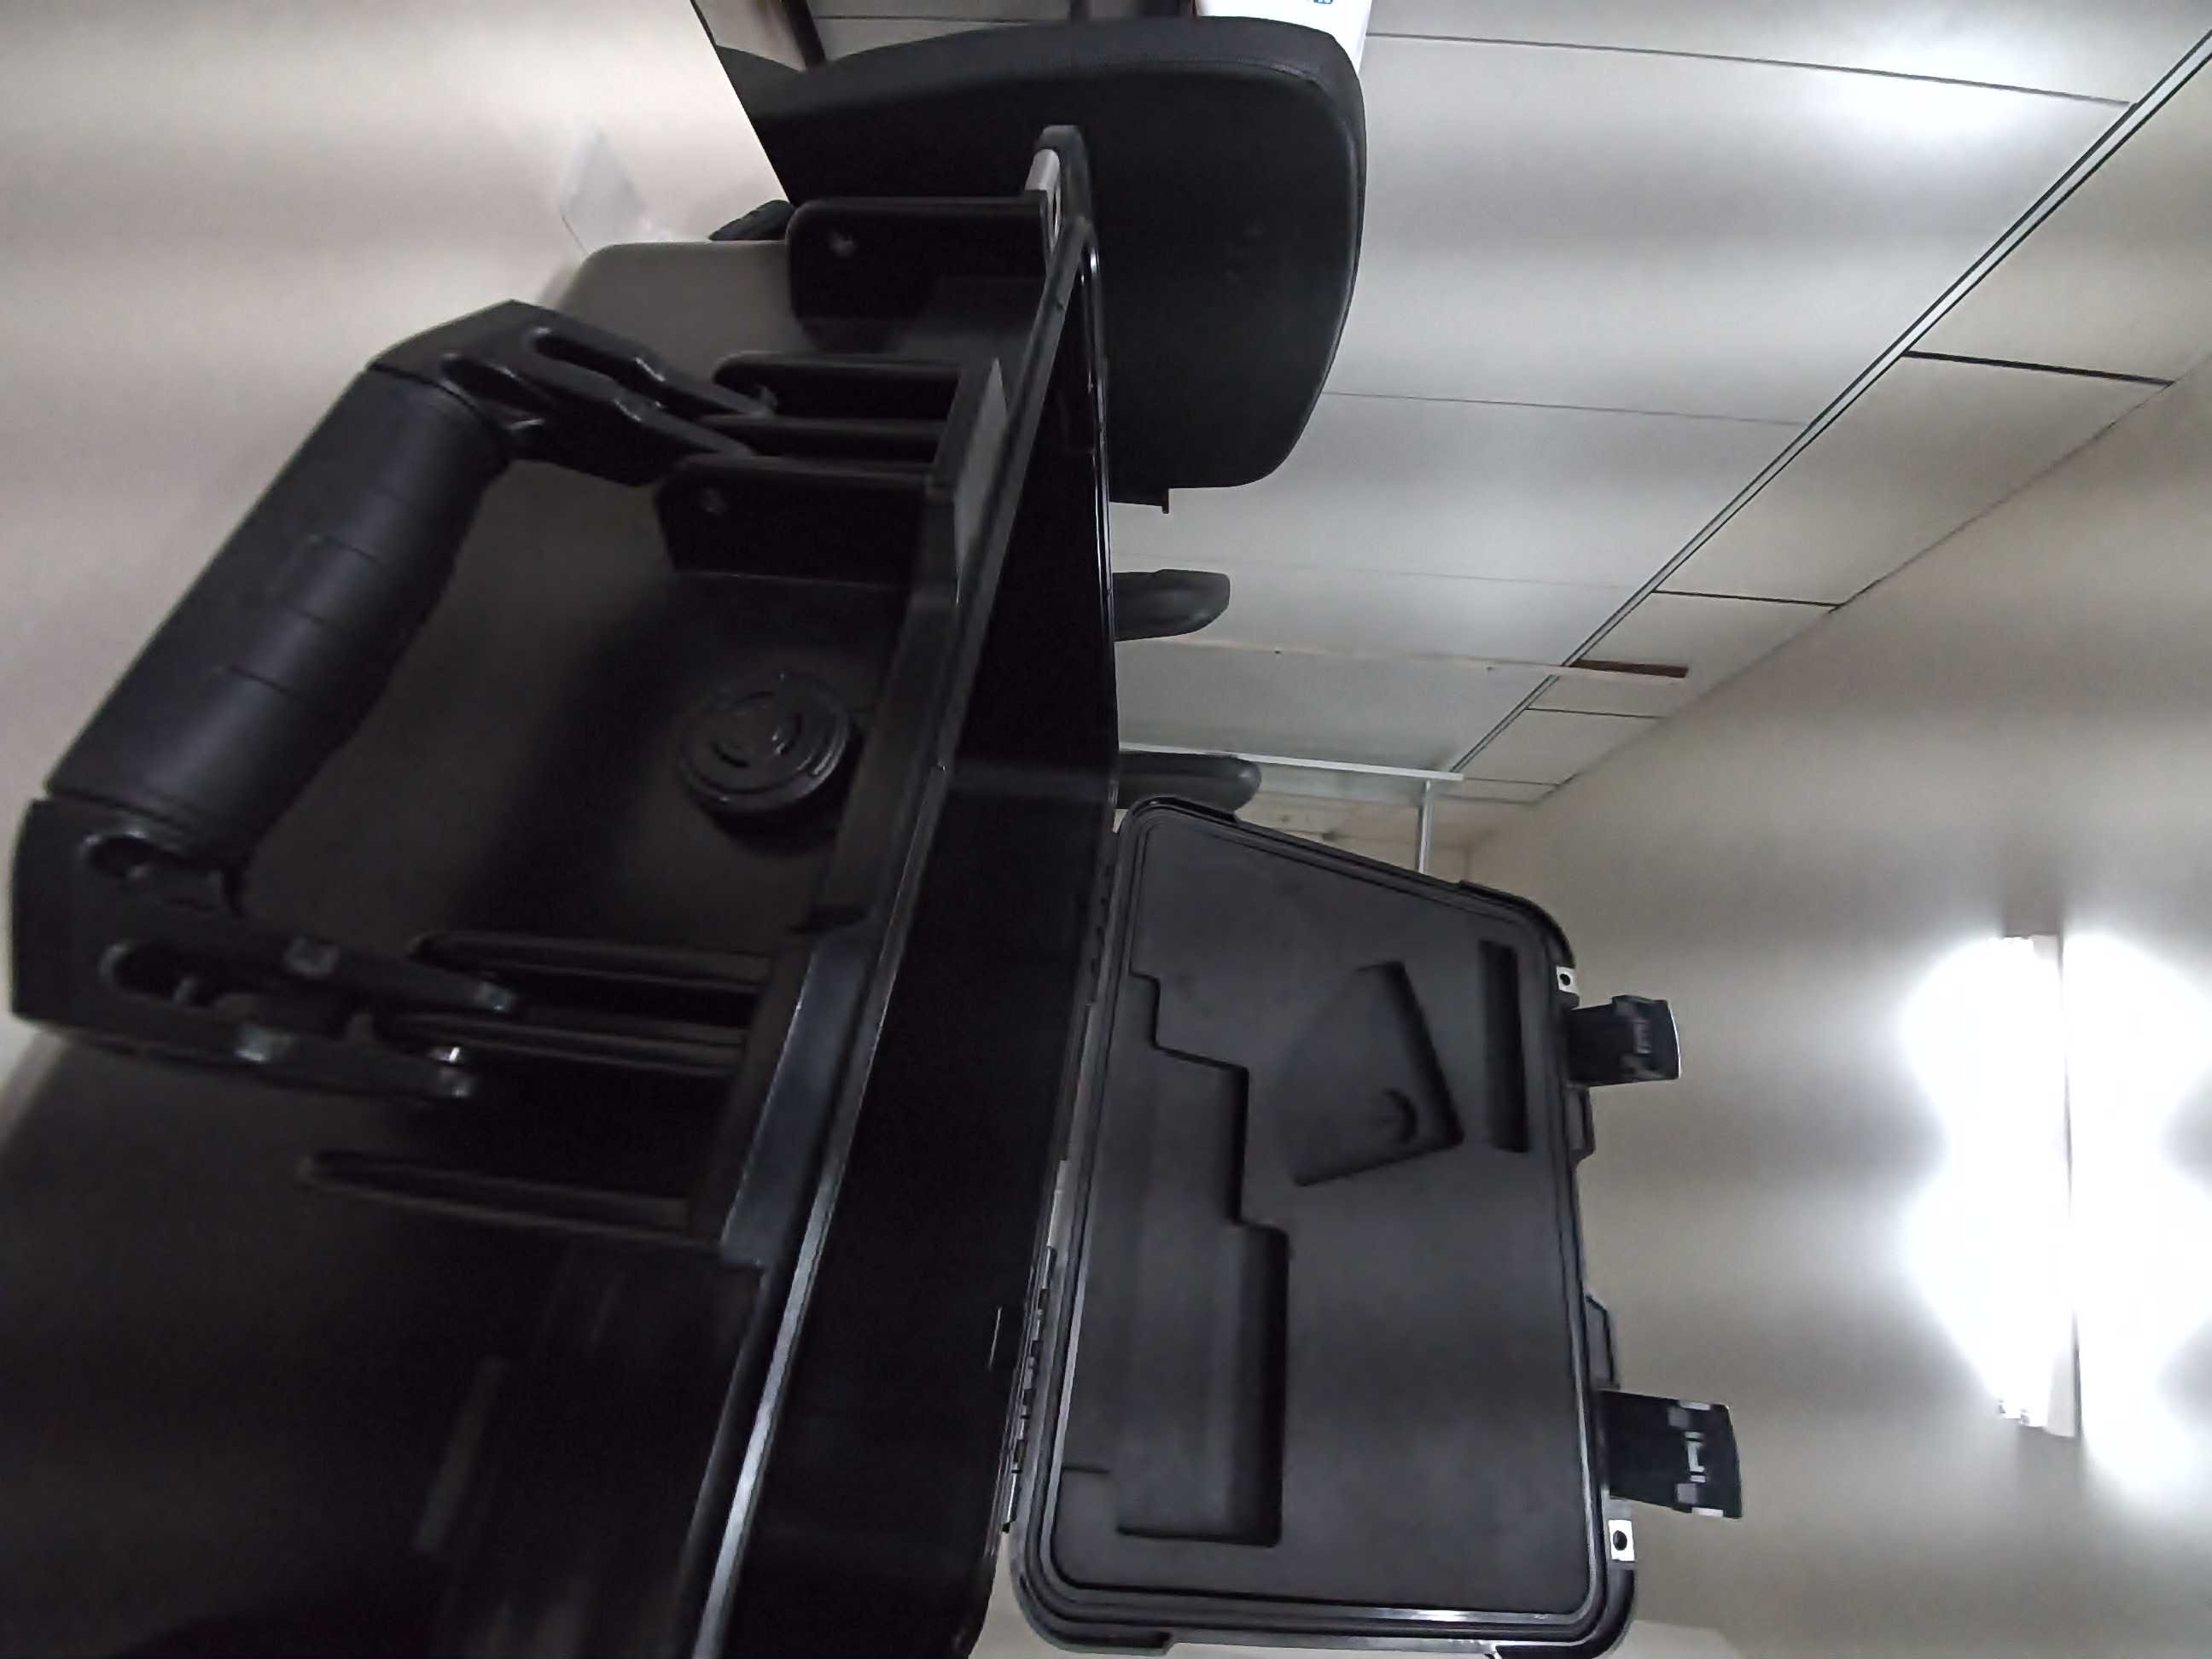

In [3]:
frames = os.listdir(os.path.join(dados_dir, "camera1"))
print("Quantidade de frames da câmera 1:", len(frames))

# Abrindo a primeira imagem da câmera 1
from PIL import Image
print(f"{frames[0]}:")
image_path = os.path.join(dados_dir, "camera1", frames[0])
image = Image.open(image_path)
image

#### 2.2 A captura UDP dos dados LiDAR `.pcap`



https://www.hesaitech.com/downloads/#xt32-16

Requisitos:
- WireShark
- [Pandar View 2](https://hesaitechnology.github.io/dev/docs/how_to_guides/PandarView/)
- [Python pypcapkit](https://jarryshaw.github.io/PyPCAPKit/)

#### 2.2.1 Wireshark

![alt text](media/imgs/ws.png)

#### 2.2.2 Pandar view

![alt text](media/imgs/pandar.png)

#### 2.2.3 Python pcapkit

In [16]:
from pcapkit import extract
import os
# Extract packets from a PCAP file
pcap_file = os.path.join(dados_dir, "20250610-163659_00040_SLAM_Pandar_0001_0.pcap")
with extract(fin=pcap_file, auto=False, store=False, nofile=True, engine="default") as capture:
    for frame in capture:
        if "UDP" not in frame:
            continue

        udp = frame["UDP"]
        first_payload = udp.packet.payload
        break

In [18]:
from pprint import pprint
print("First UDP payload:",len(first_payload), "bytes")
pprint(first_payload)

First UDP payload: 568 bytes
(b'\xee\xff\x06\x01\x00\x00\x10\x08\x00\x04\x02\x01\x1b-\x00\x00'
 b'\x00\xff\x00\x00\x00\xff\x00\x00\x00\xff\x00\x00\x00\xff\x00\x00'
 b'\x00\xff\x00\x00\x00\xff\x00\x00\x00\xff\x00\x00\x00\xff\x00\x00'
 b'\x00\xff\x00\x00\x00\xff\x00\x00\x00\xffy\x00\x01\xff\x80\x00'
 b'\x00\xff\x83\x00\x01\xff\x81\x00\x01\xff\x81\x00\x01\xff--\x00\x00\x00\xff'
 b'\x00\x00\x00\xff\x00\x00\x00\xff\x00\x00\x00\xff\x00\x00\x00\xff'
 b'\x00\x00\x00\xff\x00\x00\x00\xff\x00\x00\x00\xff\x00\x00\x00\xff'
 b'\x00\x00\x00\xff\x00\x00\x00\xff\x82\x00\x01\xff\x83\x00\x01\xff'
 b'\x84\x00\x01\xff\x82\x00\x01\xff\x80\x00\x00\xff?-\x00\x00\x00\xff\x00\x00'
 b'\x00\xff\x00\x00\x00\xff\x00\x00\x00\xff\x00\x00\x00\xff\x00\x00'
 b'\x00\xff\x00\x00\x00\xff\x00\x00\x00\xff\x00\x00\x00\xff\x00\x00'
 b'\x00\xff{\x00\x00\xff}\x00\x01\xff\x84\x00\x01\xff\x84\x00\x01\xff\x81\x00'
 b'\x01\xff\x81\x00\x00\xffQ-\x00\x00\x00\xff\x00\x00\x00\xff\x00\x00\x00\xff'
 b'\x00\x00\x00\xff\x00\x00\x00\xff\x00\

**Mas o que significam esses bytes? Sabe-se que as informações LiDAR estão aí dentro!**

#### 2.2.4 LiDAR Pandar XT16: 16-Channel Mid-Range Mechanical Lidar

**Specs:**
- Number of channels 16
- Instrumented range 0.05 to 120 m
- Horizontal FOV 360°
- Vertical FOV 30° (-15° to +15°)
- Vertical resolution 2°

**Ângulo vertical:**
<center><img src="media/imgs/pandar_xt16_channel_vertical_distribution.png" width=600></center>

In [21]:
import numpy as np
PANDAR_XT16_ELEVATION_DEG = np.arange(15.0, -16.0, -2.0)
PANDAR_XT16_ELEVATION_DEG

array([ 15.,  13.,  11.,   9.,   7.,   5.,   3.,   1.,  -1.,  -3.,  -5.,
        -7.,  -9., -11., -13., -15.])

**Data structure:** 

https://www.hesaitech.com/wp-content/uploads/2025/08/PandarXT-16_User_Manual_X02-en-250810.pdf#page=49

<center><img src="media/imgs/pandar_xt16_data_structure.png" width=600></center>

<center><img src="media/imgs/pandar_xt15_pre-header.jpeg"></center>

**Distância e ângulo horizontal (azimute):**

<center><img src="media/imgs/pandar_xt16_body.png" width=600></center>

<center><img src="media/imgs/pandar_xt15_each_point_calc.jpeg" width=600></center>

Data point $p = [x \ y \ z]^T$

$$x =  distance_{horizontal} \times \sin{\alpha} \\
y = distance_{horizontal} \times \cos{\alpha} \\
z = distance \times \sin{\beta}$$

Onde $\alpha$ é o ângulo horizontal, $\beta$ é o ângulo vertical e $distance_{horizontal} = distance \times \cos(\beta)$.

In [ ]:
# Ler o PCAP com pypcapkit e decodificar os pacotes UDP do Hesai PandarXT-16
from datetime import datetime, timedelta, timezone
import struct

import numpy as np
import pandas as pd
from pcapkit import extract

# Angulos verticais nominais dos canais 1 a 16 (manual do PandarXT-16).
# Para maior exatidao, substitua-os pelos valores do arquivo de correcao
# angular que acompanha especificamente este sensor.
PANDAR_XT16_RETURN_NAMES = {
    0x33: ("first",),
    0x37: ("strongest",),
    0x38: ("last",),
    0x39: ("last", "strongest"),
    0x3B: ("last", "first"),
    0x3C: ("first", "strongest"),
}


def _pandar_xt16_packet_time(payload):
    """Converte os campos UTC do tail do pacote para datetime."""
    tail_offset = 12 + 8 * 66
    year, month, day, hour, minute, second = payload[tail_offset + 13:tail_offset + 19]
    microsecond = struct.unpack_from("<I", payload, tail_offset + 19)[0]
    try:
        return datetime(1900 + year, month, day, hour, minute, second, tzinfo=timezone.utc) + timedelta(
            microseconds=microsecond
        )
    except ValueError:
        # O relogio pode ainda nao estar sincronizado no inicio da captura.
        return pd.NaT


def read_pandar_xt16_pcap(path, max_packets=None):
    """Extrai pontos PandarXT-16 de um PCAP para um DataFrame.

    max_packets limita somente os pacotes LiDAR validos. Use None para ler
    a captura inteira; capturas longas podem consumir muita memoria.
    """
    rows = []
    lidar_packet_count = 0
    ignored_udp_count = 0

    # auto=False e store=False fazem a leitura quadro a quadro, sem guardar
    # uma segunda copia de todo o PCAP na memoria.
    with extract(
        fin=path, auto=False, store=False, nofile=True, engine="default"
    ) as capture:
        for frame in capture:
            if "UDP" not in frame:
                continue

            udp = frame["UDP"]
            payload = udp.packet.payload

            # Pre-header 0xEEFF e estrutura fixa do PandarXT-16 v6.1:
            # 6 B pre-header + 6 B header + 8 * 66 B body + 24 B tail + 4 B seq.
            if (
                len(payload) != 568
                or payload[:2] != b"\xee\xff"
                or payload[6] != 16
                or payload[7] != 8
            ):
                ignored_udp_count += 1
                continue

            distance_unit_m = payload[9] / 1000.0
            tail_offset = 12 + 8 * 66
            return_mode = payload[tail_offset + 10]
            motor_speed_rpm = struct.unpack_from("<H", payload, tail_offset + 11)[0]
            packet_time = _pandar_xt16_packet_time(payload)
            sequence = struct.unpack_from("<I", payload, tail_offset + 24)[0]
            return_names = PANDAR_XT16_RETURN_NAMES.get(return_mode, (f"0x{return_mode:02X}",))

            for block_index in range(8):
                block_offset = 12 + block_index * 66
                reference_azimuth_deg = struct.unpack_from("<H", payload, block_offset)[0] * 0.01
                return_name = return_names[block_index % len(return_names)]

                for channel_index, elevation_deg in enumerate(PANDAR_XT16_ELEVATION_DEG):
                    channel_offset = block_offset + 2 + channel_index * 4
                    distance_raw, reflectivity = struct.unpack_from("<HB", payload, channel_offset)
                    if distance_raw == 0:
                        continue

                    distance_m = distance_raw * distance_unit_m
                    # Compensa o instante de disparo do canal (Apendice B.4).
                    firing_offset_us = 6.0 + 3.024 * channel_index
                    azimuth_deg = (
                        reference_azimuth_deg
                        + firing_offset_us * 1e-6 * motor_speed_rpm * 6.0
                    ) % 360.0
                    azimuth_rad = np.deg2rad(azimuth_deg)
                    elevation_rad = np.deg2rad(elevation_deg)
                    horizontal_distance = distance_m * np.cos(elevation_rad)

                    # Sistema do fabricante: +Y = azimute 0 graus; +Z para cima.
                    rows.append({
                        "packet": lidar_packet_count,
                        "sequence": sequence,
                        "packet_time_utc": packet_time,
                        "block": block_index + 1,
                        "channel": channel_index + 1,
                        "return": return_name,
                        "azimuth_deg": azimuth_deg,
                        "elevation_deg": elevation_deg,
                        "distance_m": distance_m,
                        "reflectivity": reflectivity,
                        "x": horizontal_distance * np.sin(azimuth_rad),
                        "y": horizontal_distance * np.cos(azimuth_rad),
                        "z": distance_m * np.sin(elevation_rad),
                    })

            lidar_packet_count += 1
            if max_packets is not None and lidar_packet_count >= max_packets:
                break

    if lidar_packet_count == 0:
        raise ValueError(
            "Nenhum pacote UDP PandarXT-16 valido foi encontrado "
            f"(pacotes UDP ignorados: {ignored_udp_count})."
        )

    points = pd.DataFrame.from_records(rows)
    print(
        f"{lidar_packet_count:,} pacotes LiDAR, {len(points):,} pontos validos "
        f"e {ignored_udp_count:,} pacotes UDP ignorados."
    )
    return points


# Le uma amostra controlada. Troque por max_packets=None para a captura inteira.
lidar_points = read_pandar_xt16_pcap(pcap_file, max_packets=1_000)
lidar_points.head()

1,000 pacotes LiDAR, 123,068 pontos validos e 0 pacotes UDP ignorados.


,packet,sequence,packet_time_utc,block,channel,return,azimuth_deg,elevation_deg,distance_m,reflectivity,x,y,z
0,0,39613,2025-06-10 16:36:59.923181+00:00,1,12,strongest,115.611350,-7.0,0.484,1,0.433192,-0.207657,-0.058985
1,0,39613,2025-06-10 16:36:59.923181+00:00,1,13,strongest,115.622237,-9.0,0.512,0,0.455969,-0.218681,-0.080094
2,0,39613,2025-06-10 16:36:59.923181+00:00,1,14,strongest,115.633123,-11.0,0.524,1,0.463749,-0.222521,-0.099984
3,0,39613,2025-06-10 16:36:59.923181+00:00,1,15,strongest,115.644010,-13.0,0.516,1,0.453252,-0.217590,-0.116075
4,0,39613,2025-06-10 16:36:59.923181+00:00,1,16,strongest,115.654896,-15.0,0.516,1,0.449283,-0.215790,-0.133551


In [24]:
lidar_points.to_csv("dados/amostras/lidar_points.csv", index=False)

#### 2.3 O arquivo de calibração contendo os parâmetros instrínsecos e extrínsecos

In [19]:
# Ler o arquivo de calibração
with open(os.path.join(dados_dir, "feima_slam100_calib.yaml"), "r") as f:
    calib_data = f.read()
    print(calib_data)

version: 20230525
parameters:
  hardware:
    slam_100-sn: SLAM100242801059
    lidar2rasterR: [0.01498514, -0.00045287, -0.00149213, 0.99988653]
    pcl2imuR: [0.00376496, 0.00057422, 0.00358588, 0.99998632]
    pcl2imuT: [0.06787, 0.00825, 0.12309]
    lidarCorrect: [-0.1, 0.0]
    code: AgAAAIKpALon5B67WklNvEjhOkCPwvU8AABgwWscFD2pCTM8AAAAAI/C9Tyq9qW8H+/5vGDfAr1cj05BEegGPCVY27yby8c8oIbqPDLbN7pN2lS8XDkHPQAAAACCLzU8NIfFPK69Cj0F1ti8CtcjPQAAAABB0zG7EaXEPNUsIbz53Y+7AAAgwQ0azDub+u68I2ASPAAAAACgKd+8AADAQPgw3rwAAAAA3zA5Op326rwp49Y8dex6vHabyDzKaNo8pAYNPQ5HvbtI4WC7xlC2PIJW2DwAAAAAcaXIvHIc/jxmaJO7Sikfux1enbwAAAAAwYnSvJuwhbzsUXDB+ijqvA7L2bwxwVc81x2qPLUN5bxfq968my9HPDwyDzxPPQI9GrXtvHxaDD24Hp1AAAAAAOzpYzzXo6DAgAe5POF63EBAKQE9QR08PAAAQMEK16M8AAAAAKheoDyd4RY91VcfPFfwyrwgZD+8essWPQ6IHD3KPh49Cv8VPblaiDsac0W8HKMYuweOi7wAAAAAAAAAAGUvMbtiji09PS4KvCfe47zGyiC8RZLrPDyr47x+l428j1GyPMY/ULxIYwo99tqAvPj0RLrJgxc8rp6NvLpm5LzjFxw9AAAAAOmAcLztrIK5jez3vEI8RzxM2D08sBi6PLChPLxVGWQ8vJ3AvLgehb9Zqq685/aHPFZogzxKFaE8BRNSv

**Traduzindo:**

mountTolaserTransform_cam0: [10.367480, 2.059794, 1.003480, 0.464824, -1.512433, 3.016278] $\rightarrow$

mountTolaserTransform_cam0: [tx, ty, tz, rx, ry, rz] $\rightarrow$

mountTolaserTransform_cam0: [tx, ty, tz, roll, pitch, yaw] $\rightarrow$

mountTolaserTransform_cam0: [tx, ty, tz, $\omega$, $\phi$, $\kappa$] $\rightarrow$

$R  = \begin{bmatrix} \cos\kappa\cos\phi &
\cos\kappa\sin\phi\sin\omega-\sin\kappa\cos\omega &
\cos\kappa\sin\phi\cos\omega+\sin\kappa\sin\omega
\\
\sin\kappa\cos\phi &
\sin\kappa\sin\phi\sin\omega+\cos\kappa\cos\omega &
\sin\kappa\sin\phi\cos\omega-\cos\kappa\sin\omega
\\
-\sin\phi &
\cos\phi\sin\omega &
\cos\phi\cos\omega \end{bmatrix}$

$
t = 
\begin{bmatrix}
t_x\\
t_y\\
t_z
\end{bmatrix} \rightarrow
T = \begin{bmatrix} R & t \\ 0 &1 \end{bmatrix} 
$

In [21]:
# Converter a calibração YAML e construir R, t e T para cada câmera
import re

import numpy as np
import yaml
from scipy.spatial.transform import Rotation

calib_dict = yaml.safe_load(calib_data)
calib_params = calib_dict["parameters"]["param"]

camera_extrinsics_transforms = {}
for key, pose_values in calib_params.items():
    match = re.fullmatch(r"mountTolaserTransform_(cam\d+)", key)
    if match is None:
        continue

    # Convenção do arquivo: [tx, ty, tz, rx, ry, rz], em que
    # [rx, ry, rz] é um vetor de rotação (Rodrigues), em radianos.
    pose = np.asarray(pose_values, dtype=float)
    if pose.shape != (6,):
        raise ValueError(f"{key} deve conter exatamente 6 valores; recebeu {pose.shape}.")

    translation = pose[:3].reshape(3, 1)
    rotation = Rotation.from_rotvec(pose[3:]).as_matrix()
    transformation = np.eye(4)
    transformation[:3, :3] = rotation
    transformation[:3, 3:] = translation

    camera_extrinsics_transforms[match.group(1)] = {
        "rotation": rotation,
        "translation": translation,
        "transformation": transformation,
    }

if not camera_extrinsics_transforms:
    raise ValueError("Nenhuma transformação de câmera foi encontrada na calibração.")

for frame, matrices in sorted(camera_extrinsics_transforms.items()):
    print(f"{frame}:")
    print("R =\n", matrices["rotation"])
    print("t =\n", matrices["translation"])
    print("T =\n", matrices["transformation"], "\n")

cam0:
R =
 [[-0.92862442  0.11241809  0.35358006]
 [-0.35059221 -0.5777415  -0.73708877]
 [ 0.12141576 -0.80844105  0.57591778]]
t =
 [[10.36748 ]
 [ 2.059794]
 [ 1.00348 ]]
T =
 [[-0.92862442  0.11241809  0.35358006 10.36748   ]
 [-0.35059221 -0.5777415  -0.73708877  2.059794  ]
 [ 0.12141576 -0.80844105  0.57591778  1.00348   ]
 [ 0.          0.          0.          1.        ]] 

cam1:
R =
 [[ 0.09827153  0.25474387  0.96200222]
 [ 0.42488523  0.8634048  -0.27203805]
 [-0.89989735  0.43547413 -0.0233888 ]]
t =
 [[10.438683]
 [ 2.065577]
 [ 1.003035]]
T =
 [[ 0.09827153  0.25474387  0.96200222 10.438683  ]
 [ 0.42488523  0.8634048  -0.27203805  2.065577  ]
 [-0.89989735  0.43547413 -0.0233888   1.003035  ]
 [ 0.          0.          0.          1.        ]] 

cam2:
R =
 [[-0.19287675 -0.65655491  0.72920108]
 [ 0.30954051 -0.74592097 -0.58973433]
 [ 0.93111934  0.11197124  0.34710115]]
t =
 [[10.402378]
 [ 2.084573]
 [ 0.999105]]
T =
 [[-0.19287675 -0.65655491  0.72920108 10.402378  

camera_instrinsic_parameters_cam0: [2592, 1944, 2.000000, 1257.922590, 971.037405, 1014.462884, -6.928276e-08, 8.981671e-14, -3.313502e-20, 4.943206e-27, 1.361688e-07, 8.805451e-08, 3.501730e-04, 4.023858e-04] $\rightarrow$

In [29]:
# Construir a matriz intrínseca K e obter os coeficientes de distorção da cameras
camera_intrinsic_transforms = {}
for key, pose_values in calib_params.items():
    match = re.fullmatch(r"camera_instrinsic_parameters_(cam\d+)", key)
    if match is None:
        continue

    intrinsic_values = np.asarray(
        calib_params[f"camera_instrinsic_parameters_{match.group(1)}"], dtype=float
    )

    if intrinsic_values.shape != (14,):
        raise ValueError(
            f"camera_instrinsic_parameters_{match.group(1)} deve conter exatamente 14 valores; "
            f"recebeu {intrinsic_values.shape}."
        )

    image_width, image_height = intrinsic_values[:2].astype(int)
    unknown_parameter  = intrinsic_values[2]
    cx, cy, focal_length = intrinsic_values[3:6]
    # Os oito valores restantes são preservados na ordem fornecida pelo fabricante.
    distortion_coefficients_maybe = intrinsic_values[6:].copy()

    K = np.array([
        [focal_length, 0.0, cx],
        [0.0, focal_length, cy],
        [0.0, 0.0, 1.0],
    ])

    camera_intrinsic_transforms[match.group(1)] = {
        "K": K,
        "distortion_coefficients_maybe": distortion_coefficients_maybe
    }

for frame, matrices in sorted(camera_intrinsic_transforms.items()):
    print(f"{frame.upper()}:")
    print(f"Resolução: {image_width} x {image_height}")
    print(f"K_{frame} =\n", matrices["K"])
    print(f"Coeficientes de distorção_{frame} =\n", matrices["distortion_coefficients_maybe"])

CAM0:
Resolução: 2592 x 1944
K_cam0 =
 [[1.01446288e+03 0.00000000e+00 1.25792259e+03]
 [0.00000000e+00 1.01446288e+03 9.71037405e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Coeficientes de distorção_cam0 =
 [-6.928276e-08  8.981671e-14 -3.313502e-20  4.943206e-27  1.361688e-07
  8.805451e-08  3.501730e-04  4.023858e-04]
CAM1:
Resolução: 2592 x 1944
K_cam1 =
 [[1.01284411e+03 0.00000000e+00 1.32297409e+03]
 [0.00000000e+00 1.01284411e+03 9.09882371e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Coeficientes de distorção_cam1 =
 [-9.573304e-08  1.493661e-13 -8.585460e-20  2.045918e-26 -1.573257e-09
  3.855574e-07  7.051441e-04 -1.094656e-04]
CAM2:
Resolução: 2592 x 1944
K_cam2 =
 [[1.01590100e+03 0.00000000e+00 1.28424480e+03]
 [0.00000000e+00 1.01590100e+03 9.26318826e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Coeficientes de distorção_cam2 =
 [-6.982101e-08  8.949502e-14 -3.389261e-20  5.363045e-27  2.891150e-07
 -7.399529e-08  9.276531e-05 -2.074312e-04]
